Logistic Regression

$$f(x) = wx + b
\\
h(x) = \frac{1}{1 + e^z}

In [60]:
import numpy as np
import matplotlib.pyplot as plt

In [61]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, random_state=42, n_clusters_per_class=1)

In [62]:
X.shape, y.shape

((1000, 2), (1000,))

In [63]:
X[:5], y[:5]

(array([[ 0.60103418,  1.5353525 ],
        [ 0.75594526, -1.1723519 ],
        [ 1.35447877, -0.94852841],
        [ 3.1030897 ,  0.23348484],
        [ 0.75317779,  0.78751427]]),
 array([1, 0, 0, 0, 1]))

Train Test Split

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The Sigmoid Function

In [65]:
def sigmoid(X, w, b):
    return 1 / (1 + np.exp(-((X @ w) + b)))

In [66]:
def compute_cost(X, y, w, b):
    m = len(y)
    h = sigmoid(X, w, b)
    epsilon = 1e-15 
    cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1-y) * np.log(1 - h + epsilon))
    return cost

In [67]:
def compute_derivatives(X, y, w, b):
    m = len(y)
    h = sigmoid(X, w, b)
    dw = (1/m) * (X.T @ (h - y))
    db = (1/m) * np.sum(h - y)
    return dw, db

In [68]:
def fit(X, y, lr=0.01, n_iters=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    history = []

    for _ in range(n_iters):
        y_predicted = sigmoid(X, weights, bias)
        dw, db = compute_derivatives(X, y, weights, bias)

        weights -= lr * dw
        bias -= lr * db

        cost = compute_cost(X, y, weights, bias)
        history.append(cost)

        if _ % 100 == 0:
            print(f"Cost at iteration {_}: {cost}")

    return weights, bias, history

In [69]:
w, b, history = fit(X_train, y_train)

Cost at iteration 0: 0.6907960898617852
Cost at iteration 100: 0.5250154511021248
Cost at iteration 200: 0.43992838807061574
Cost at iteration 300: 0.3904601533843977
Cost at iteration 400: 0.3586522719843436


Cost at iteration 500: 0.33665352200253984
Cost at iteration 600: 0.3206081501051055
Cost at iteration 700: 0.3084288192408941
Cost at iteration 800: 0.2988948444121515
Cost at iteration 900: 0.29124725902217513


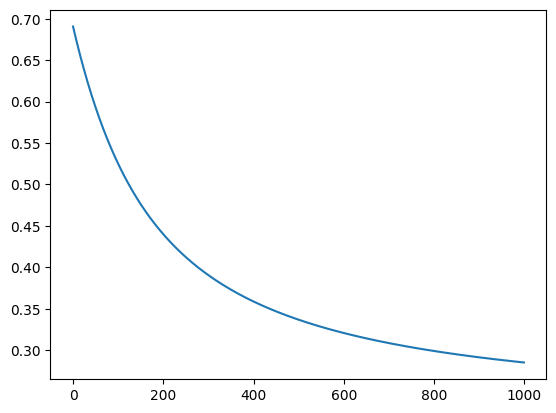

In [70]:
plt.plot(history)

Predict

In [71]:
def predict(X):
    y_predicted = sigmoid(X, w, b)
    y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
    return np.array(y_predicted_cls)

In [72]:
predictions = predict(X_test)
predictions[:10], y_test[:10]

(array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0]), array([1, 0, 0, 0, 0, 1, 1, 1, 0, 0]))

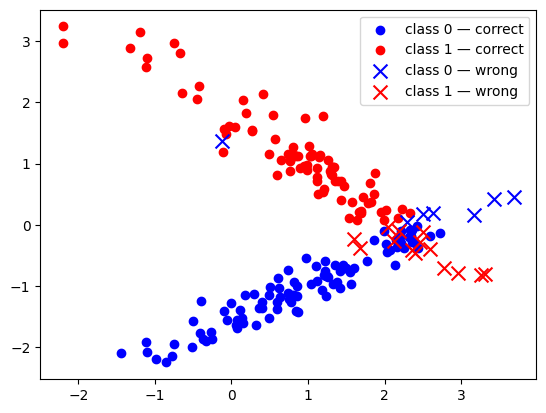

In [73]:
correct = predictions == y_test

plt.scatter(X_test[correct & (y_test==0), 0], X_test[correct & (y_test==0), 1],
            c='blue', marker='o', label='class 0 — correct')
plt.scatter(X_test[correct & (y_test==1), 0], X_test[correct & (y_test==1), 1],
            c='red', marker='o', label='class 1 — correct')
plt.scatter(X_test[~correct & (y_test==0), 0], X_test[~correct & (y_test==0), 1],
            c='blue', marker='x', s=100, label='class 0 — wrong')
plt.scatter(X_test[~correct & (y_test==1), 0], X_test[~correct & (y_test==1), 1],
            c='red', marker='x', s=100, label='class 1 — wrong')
plt.legend()
plt.show()


Decision Boundary

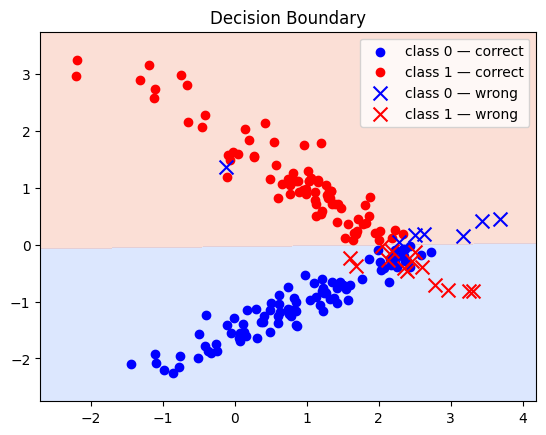

In [74]:
x1_min, x1_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
x2_min, x2_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))
grid = np.c_[xx1.ravel(), xx2.ravel()]
Z = sigmoid(grid, w, b).reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], cmap='coolwarm', alpha=0.3)

correct = predictions == y_test
plt.scatter(X_test[correct & (y_test==0), 0], X_test[correct & (y_test==0), 1],
            c='blue', marker='o', label='class 0 — correct')
plt.scatter(X_test[correct & (y_test==1), 0], X_test[correct & (y_test==1), 1],
            c='red', marker='o', label='class 1 — correct')
plt.scatter(X_test[~correct & (y_test==0), 0], X_test[~correct & (y_test==0), 1],
            c='blue', marker='x', s=100, label='class 0 — wrong')
plt.scatter(X_test[~correct & (y_test==1), 0], X_test[~correct & (y_test==1), 1],
            c='red', marker='x', s=100, label='class 1 — wrong')

plt.legend()
plt.title('Decision Boundary')
plt.show()